## Modelos subrogados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import joblib
import warnings
import os
import random
from itertools import product
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution
from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.algorithm.multiobjective.spea2 import SPEA2
from jmetal.algorithm.multiobjective import NSGAII
from jmetal.algorithm.multiobjective.nsgaiii import NSGAIII, UniformReferenceDirectionFactory
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions
from jmetal.core.quality_indicator import (
    GenerationalDistance, InvertedGenerationalDistance,
    EpsilonIndicator, HyperVolume
)

SEED = 42
random.seed(SEED) 
np.random.seed(SEED)

FEATURE_COLS  = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
FEATURE_NAMES = ['hm', 'αm', 'er', 'dsi', 'bst', 'bss']
OBJECTIVE_COLS  = ['y1', 'y2', 'y3', 'y4']
OBJECTIVE_NAMES = ['TC (material cost)','T_cogPP (cogging)','-η_ed (efficiency)','T_rippPP (ripple)']

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:

df = pd.read_csv('Datos/Originales/Datos/01_Optimización/Opt_dataset_4Objectives_CC.csv')
print(f'Dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.describe().round(4)

Dataset shape: (1700, 10)
Missing values: 0


,x1,x2,x3,x4,x5,x6,y1,y2,y3,y4
count,1700.0000,1700.0000,1700.0000,1700.0000,1700.0000,1700.0000,1700.0000,1700.0000,1700.0000,1700.0000
mean,2.1618,0.8584,1.4046,0.9934,46.1529,4.7294,6.1901,0.0757,-0.8813,0.0909
std,1.1067,0.0964,0.4146,0.9516,1.1296,0.5467,1.2640,0.0789,0.0506,0.0834
min,1.0000,0.7000,0.6000,0.0000,45.0000,3.5000,4.4581,0.0002,-0.9219,0.0014
25%,1.2000,0.7500,1.1000,0.1000,45.0000,4.7000,5.0661,0.0118,-0.9178,0.0247
50%,1.6000,0.9000,1.4000,0.7000,46.0000,4.8000,5.8431,0.0429,-0.9100,0.0612
75%,3.2000,0.9000,1.8000,2.1000,46.5000,5.1000,7.3047,0.1262,-0.8529,0.1522
max,4.0000,1.0000,2.0000,2.5000,49.5000,5.9000,9.7117,0.5543,-0.6625,0.5130


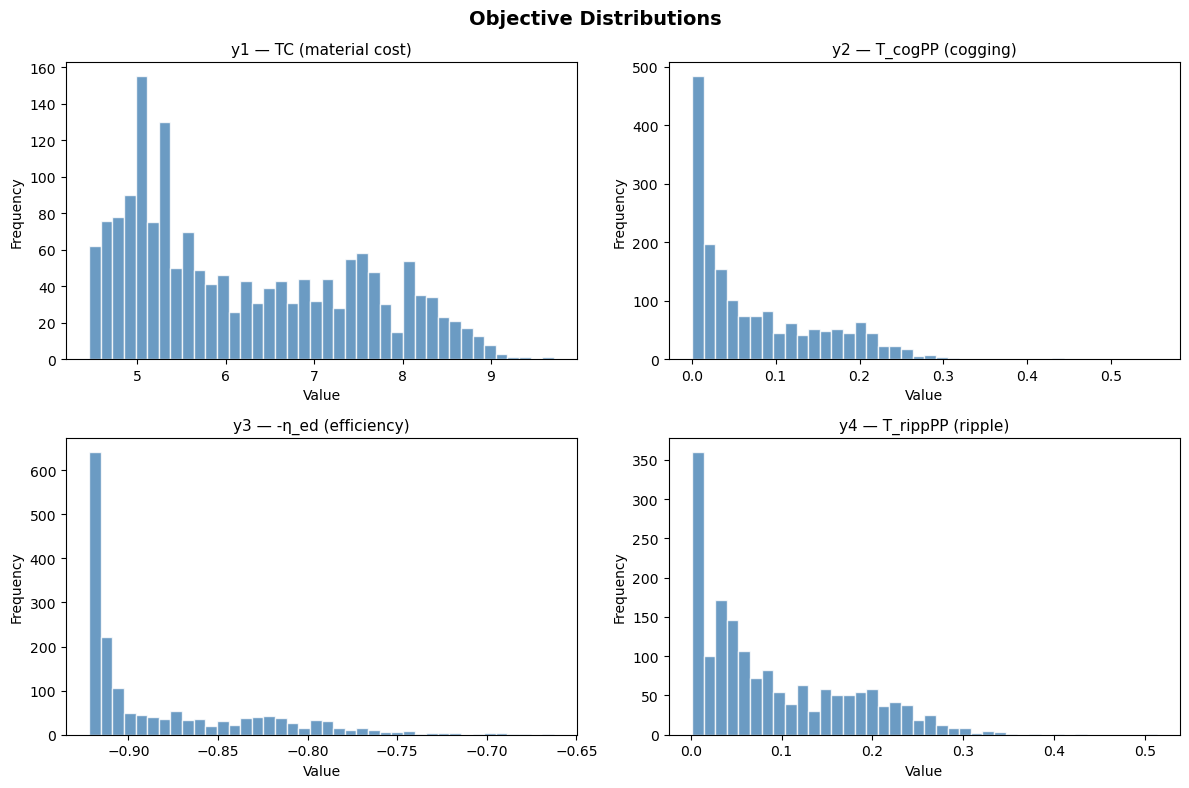

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, (col, name) in enumerate(zip(OBJECTIVE_COLS, OBJECTIVE_NAMES)):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} — {name}', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
plt.suptitle('Objective Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

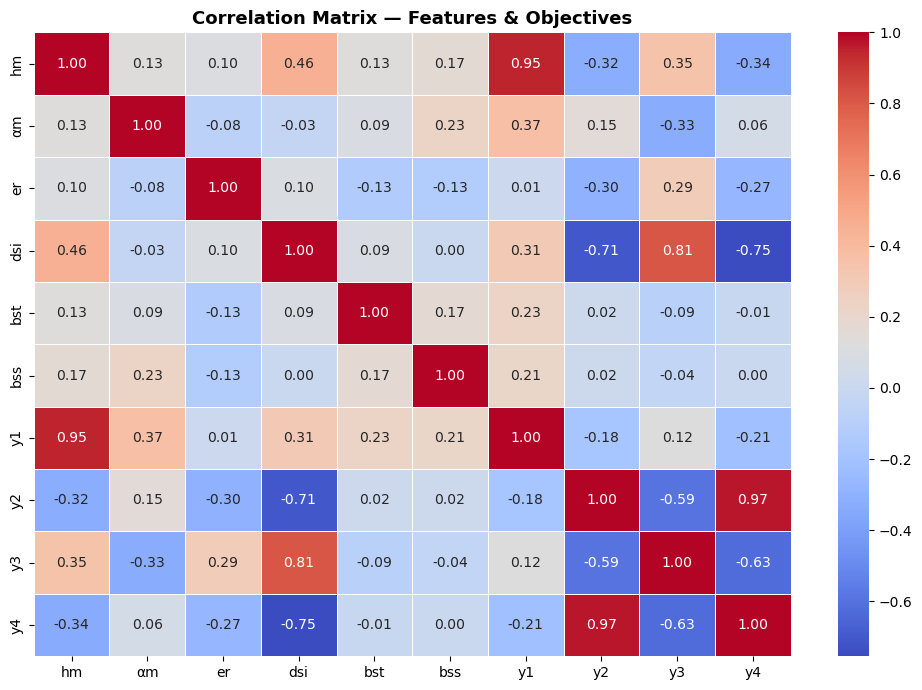

In [4]:
plt.figure(figsize=(10, 7))
corr = df.rename(columns=dict(zip(
    FEATURE_COLS + OBJECTIVE_COLS,
    FEATURE_NAMES + OBJECTIVE_COLS
))).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Features & Objectives', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
X = df[FEATURE_COLS].values
Y = df[OBJECTIVE_COLS].values  

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=SEED
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')

Train: 1360 samples
Test : 340 samples


In [6]:
pipelines = {
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(random_state=SEED, n_jobs=-1))
    ]),
    'GradientBoosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingRegressor(random_state=SEED))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  XGBRegressor(random_state=SEED, verbosity=0, n_jobs=-1))
    ]),
    'AdaBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=4),
            random_state=SEED
        ))
    ])
}

param_grids = {
    'RandomForest': {
        'model__n_estimators':      [100, 200, 300],
        'model__max_depth':         [None, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__max_features':      ['sqrt', 'log2']
    },
    'GradientBoosting': {
        'model__n_estimators':  [100, 200, 300],
        'model__max_depth':     [3, 5, 7],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__subsample':     [0.8, 1.0],
        'model__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'model__n_estimators':  [100, 200, 300],
        'model__max_depth':     [3, 5, 7],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__subsample':     [0.8, 1.0]
    },
    'AdaBoost': {
        'model__n_estimators':  [100, 200, 300],
        'model__learning_rate': [0.01, 0.1, 0.5, 1.0],
        'model__estimator__max_depth': [3, 4, 6]
    }
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [7]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'r2':   round(r2_score(y_te, y_pred), 4),
        'mae':  round(mean_absolute_error(y_te, y_pred), 6),
        'rmse': round(np.sqrt(mean_squared_error(y_te, y_pred)), 6)
    }

all_results = {}
best_models = {}
best_names  = {}

for obj_idx, (obj_col, obj_name) in enumerate(zip(OBJECTIVE_COLS, OBJECTIVE_NAMES)):
    print(f'\n{"="*60}')
    print(f'  Objective {obj_idx+1}: {obj_col} — {obj_name}')
    print(f'{"="*60}')

    y_train = Y_train[:, obj_idx]
    y_test  = Y_test[:, obj_idx]

    obj_results = {}
    best_r2    = -np.inf
    best_model = None
    best_name  = None

    for alg_name, pipeline in pipelines.items():
        print(f'\n  [{alg_name}] Running GridSearchCV...')

        gs = GridSearchCV(
            estimator  = pipeline,
            param_grid = param_grids[alg_name],
            cv         = cv,
            scoring    = 'r2',
            n_jobs     = -1,
            refit      = True
        )
        gs.fit(X_train, y_train)

        metrics = evaluate(gs.best_estimator_, X_train, y_train, X_test, y_test)
        metrics['best_params']    = gs.best_params_
        metrics['cv_best_score']  = round(gs.best_score_, 4)
        obj_results[alg_name]     = metrics

        print(f'    CV R²: {metrics["cv_best_score"]}  |  Test R²: {metrics["r2"]}  |  '
              f'MAE: {metrics["mae"]}  |  RMSE: {metrics["rmse"]}')
        print(f'    Best params: {gs.best_params_}')

        if metrics['r2'] > best_r2:
            best_r2    = metrics['r2']
            best_model = gs.best_estimator_
            best_name  = alg_name

    all_results[obj_col] = obj_results
    best_models[obj_col] = best_model
    best_names[obj_col]  = best_name

    print(f'\n  Best model for {obj_col}: {best_name} (R² = {best_r2})')




  Objective 1: y1 — TC (material cost)

  [RandomForest] Running GridSearchCV...
    CV R²: 0.9912  |  Test R²: 0.9919  |  MAE: 0.063703  |  RMSE: 0.120115
    Best params: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 300}

  [GradientBoosting] Running GridSearchCV...
    CV R²: 0.9992  |  Test R²: 0.9992  |  MAE: 0.021857  |  RMSE: 0.036606
    Best params: {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 300, 'model__subsample': 0.8}

  [XGBoost] Running GridSearchCV...
    CV R²: 0.9992  |  Test R²: 0.9993  |  MAE: 0.02099  |  RMSE: 0.035401
    Best params: {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}

  [AdaBoost] Running GridSearchCV...
    CV R²: 0.9925  |  Test R²: 0.9928  |  MAE: 0.080423  |  RMSE: 0.113025
    Best params: {'model__estimator__max_depth': 6, 'model__learning_rate': 0.5, 'model__

In [8]:
rows = []
for obj_col, obj_name in zip(OBJECTIVE_COLS, OBJECTIVE_NAMES):
    for alg_name, metrics in all_results[obj_col].items():
        rows.append({
            'Objective': f'{obj_col} ({obj_name[:12]})',
            'Algorithm': alg_name,
            'CV R²':    metrics['cv_best_score'],
            'Test R²':  metrics['r2'],
            'MAE':      metrics['mae'],
            'RMSE':     metrics['rmse'],
            'Selected': '✔' if alg_name == best_names[obj_col] else ''
        })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

        Objective        Algorithm  CV R²  Test R²      MAE     RMSE Selected
y1 (TC (material)     RandomForest 0.9912   0.9919 0.063703 0.120115         
y1 (TC (material) GradientBoosting 0.9992   0.9992 0.021857 0.036606         
y1 (TC (material)          XGBoost 0.9992   0.9993 0.020990 0.035401        ✔
y1 (TC (material)         AdaBoost 0.9925   0.9928 0.080423 0.113025         
y2 (T_cogPP (cog)     RandomForest 0.9044   0.8839 0.011175 0.028561         
y2 (T_cogPP (cog) GradientBoosting 0.9341   0.9259 0.008140 0.022814         
y2 (T_cogPP (cog)          XGBoost 0.9318   0.9375 0.007290 0.020949        ✔
y2 (T_cogPP (cog)         AdaBoost 0.8953   0.8879 0.014175 0.028064         
y3 (-η_ed (effic)     RandomForest 0.9680   0.9802 0.003481 0.006887         
y3 (-η_ed (effic) GradientBoosting 0.9694   0.9875 0.002421 0.005480        ✔
y3 (-η_ed (effic)          XGBoost 0.9708   0.9816 0.003529 0.006650         
y3 (-η_ed (effic)         AdaBoost 0.9571   0.9717 0.005231 0.00

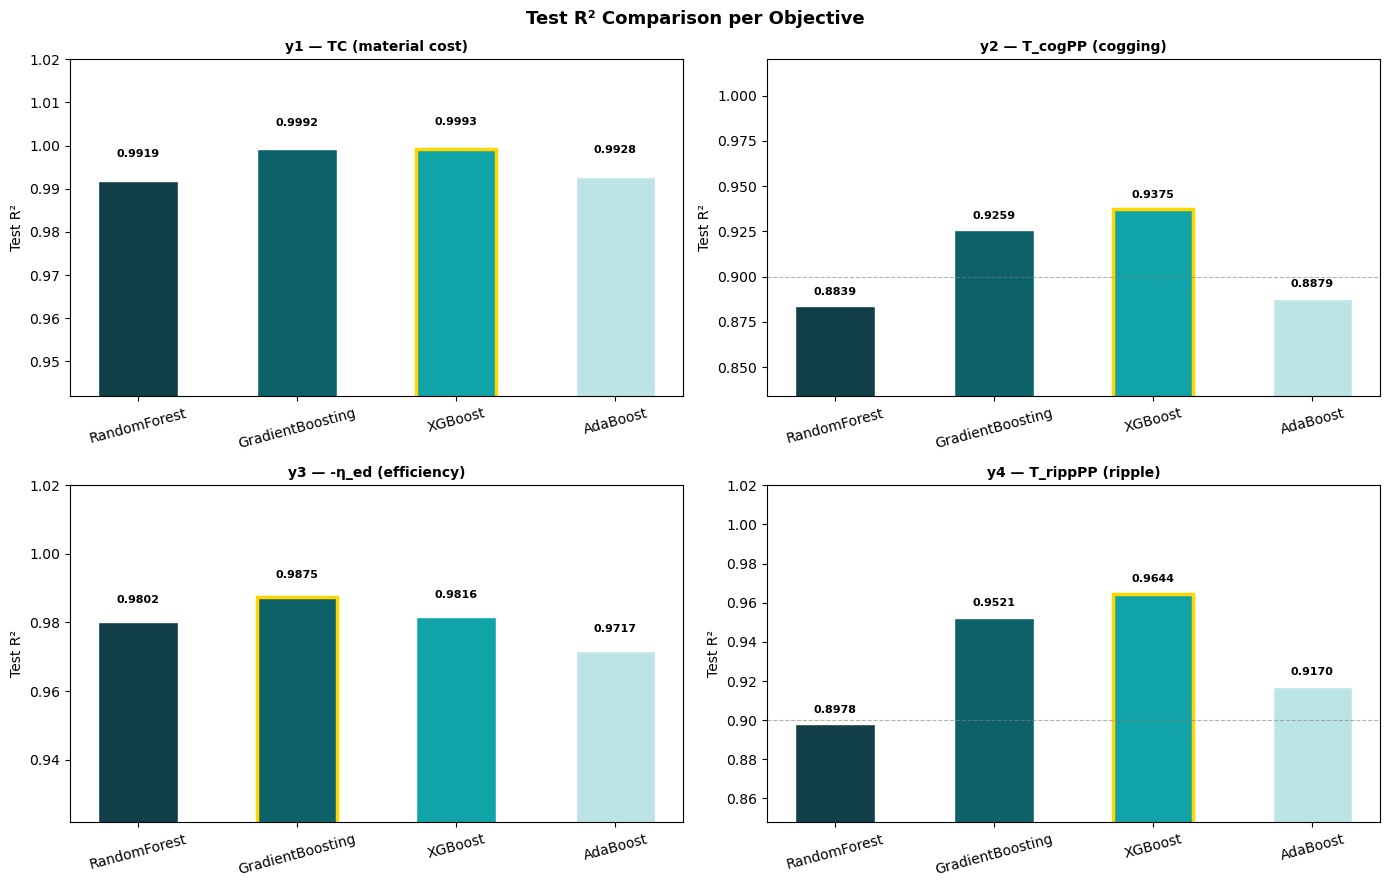

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors = {
    'RandomForest':    '#113f48',
    'GradientBoosting':'#0d626a',
    'XGBoost':         '#10a3a7',
    'AdaBoost':        '#bce4e5'
}

for i, (obj_col, obj_name) in enumerate(zip(OBJECTIVE_COLS, OBJECTIVE_NAMES)):
    algs       = list(all_results[obj_col].keys())
    r2_vals    = [all_results[obj_col][a]['r2'] for a in algs]
    bar_colors = [colors[a] for a in algs]

    bars = axes[i].bar(algs, r2_vals, color=bar_colors, edgecolor='white', width=0.5)
    axes[i].set_title(f'{obj_col} — {obj_name}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Test R²')
    axes[i].set_ylim([max(0, min(r2_vals) - 0.05), 1.02])
    axes[i].axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[i].tick_params(axis='x', rotation=15)

    for bar, val in zip(bars, r2_vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    winner_idx = algs.index(best_names[obj_col])
    bars[winner_idx].set_edgecolor('gold')
    bars[winner_idx].set_linewidth(2.5)

plt.suptitle('Test R² Comparison per Objective',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
rows = []
for obj_col, obj_name in zip(OBJECTIVE_COLS, OBJECTIVE_NAMES):
    for alg_name, metrics in all_results[obj_col].items():
        rows.append({
            'Objective':    obj_col,
            'Objective_name': obj_name,
            'Algorithm':    alg_name,
            'CV_R2':        metrics['cv_best_score'],
            'Test_R2':      metrics['r2'],
            'MAE':          metrics['mae'],
            'RMSE':         metrics['rmse'],
            'Selected':     1 if alg_name == best_names[obj_col] else 0
        })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv('Datos/Transformados/MOO/surrogate_metrics.csv', index=False)

summary_rows = []
for obj_col in OBJECTIVE_COLS:
    m = all_results[obj_col][best_names[obj_col]]
    summary_rows.append({
        'Objective':   obj_col,
        'Algorithm':   best_names[obj_col],
        'CV_R2':       m['cv_best_score'],
        'Test_R2':     m['r2'],
        'MAE':         m['mae'],
        'RMSE':        m['rmse'],
        'Best_params': str(m['best_params'])
    })

summary_df = pd.DataFrame(summary_rows)

for i, obj_col in enumerate(OBJECTIVE_COLS):
    y_true = Y_test[:, i]
    y_pred = best_models[obj_col].predict(X_test)

    pred_df = pd.DataFrame({
        'actual':    y_true,
        'predicted': y_pred,
        'residual':  y_true - y_pred,
        'objective': obj_col,
        'algorithm': best_names[obj_col]
    })


fi_rows = []
for obj_col in OBJECTIVE_COLS:
    estimator = best_models[obj_col].named_steps['model']
    if hasattr(estimator, 'feature_importances_'):
        for fname, imp in zip(FEATURE_NAMES, estimator.feature_importances_):
            fi_rows.append({
                'Objective':  obj_col,
                'Algorithm':  best_names[obj_col],
                'Feature':    fname,
                'Importance': imp
            })


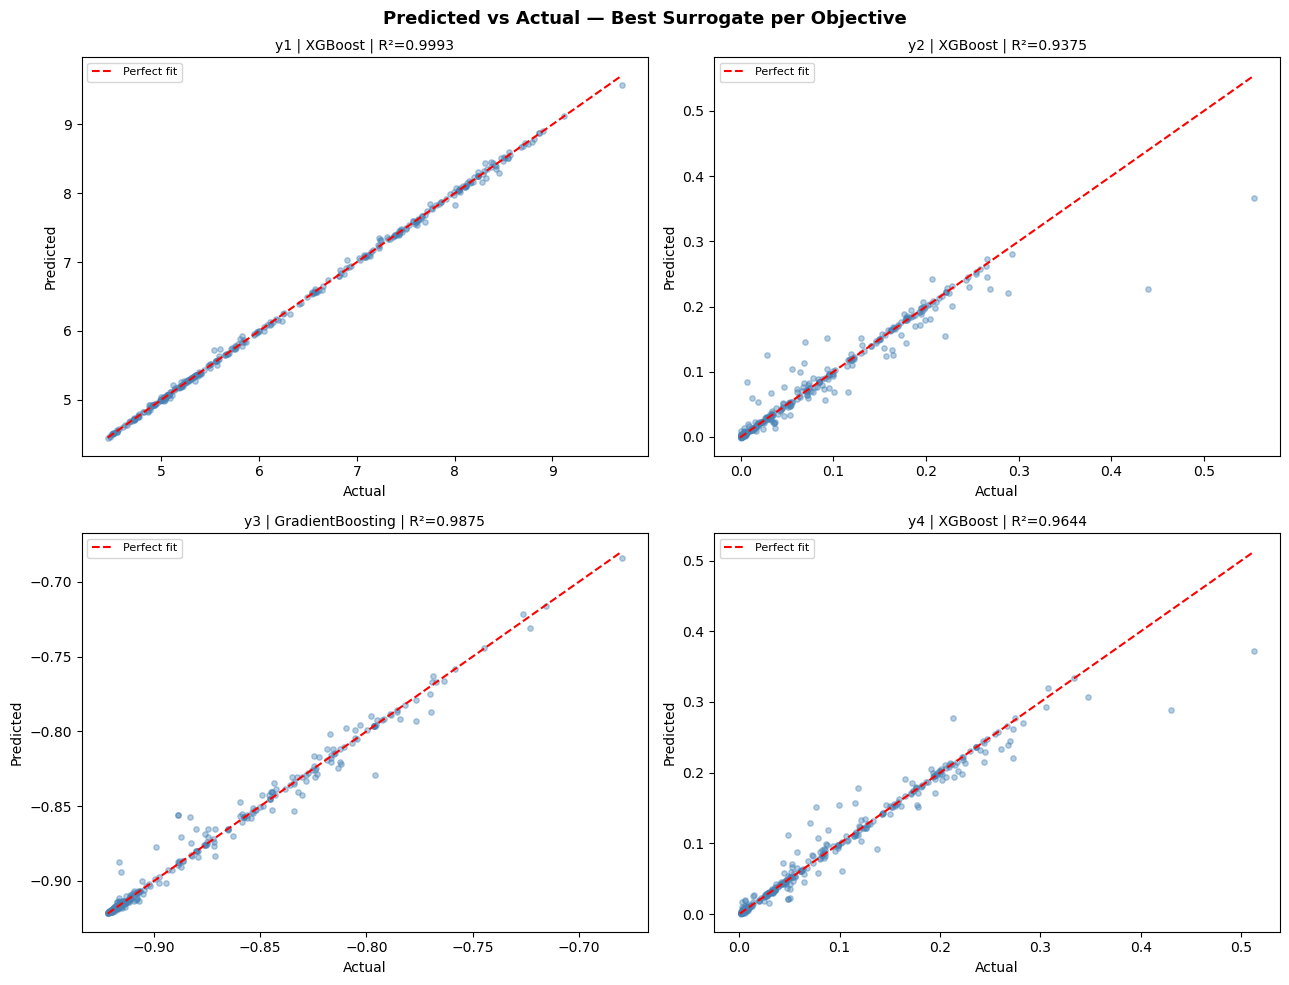

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (obj_col, obj_name) in enumerate(zip(OBJECTIVE_COLS, OBJECTIVE_NAMES)):
    model  = best_models[obj_col]
    y_true = Y_test[:, i]
    y_pred = model.predict(X_test)

    axes[i].scatter(y_true, y_pred, alpha=0.4, s=15, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[i].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(
        f'{obj_col} | {best_names[obj_col]} | R²={all_results[obj_col][best_names[obj_col]]["r2"]}',
        fontsize=10
    )
    axes[i].legend(fontsize=8)

plt.suptitle('Predicted vs Actual — Best Surrogate per Objective',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

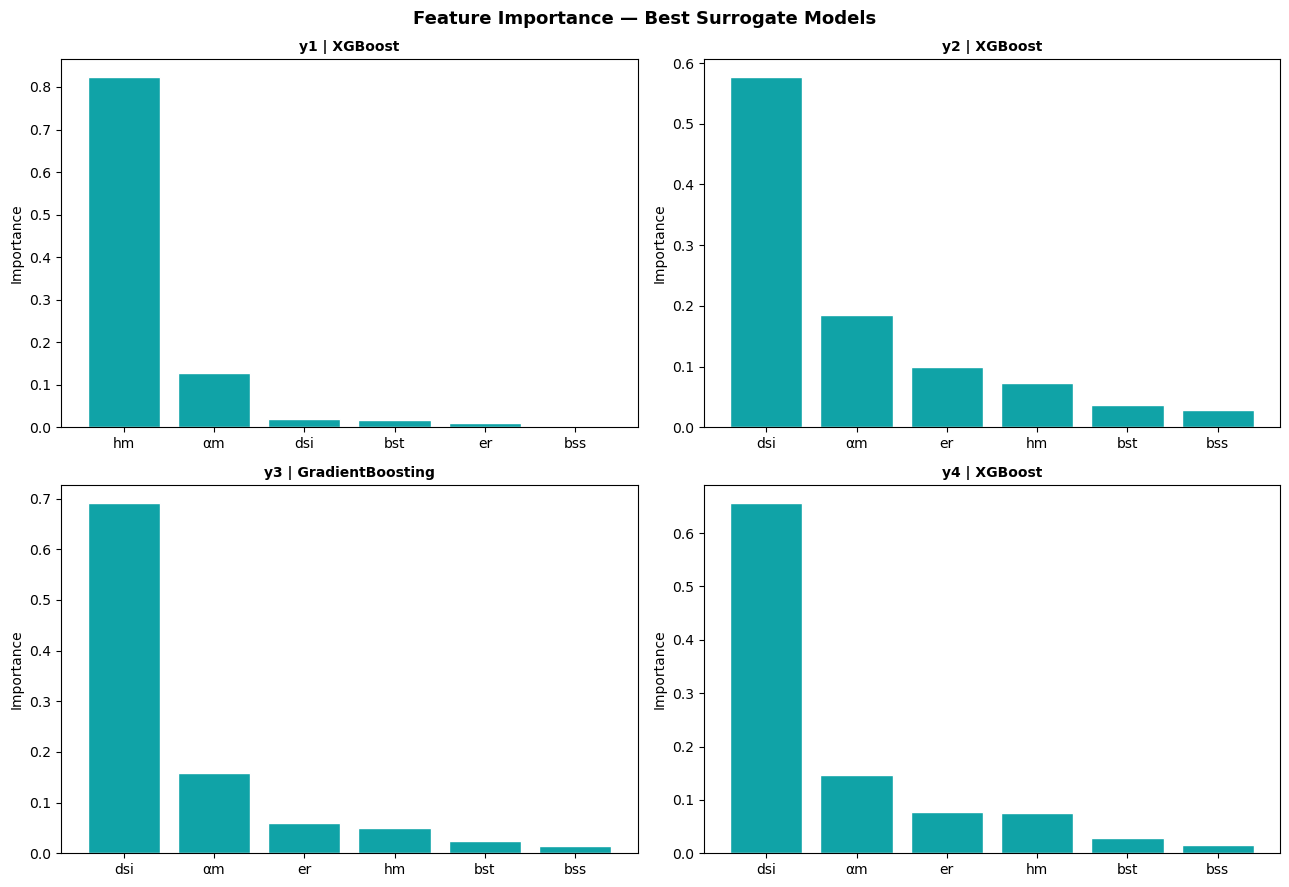

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (obj_col, obj_name) in enumerate(zip(OBJECTIVE_COLS, OBJECTIVE_NAMES)):
    estimator = best_models[obj_col].named_steps['model']

    if hasattr(estimator, 'feature_importances_'):
        importances = estimator.feature_importances_
        sorted_idx  = np.argsort(importances)[::-1]
        axes[i].bar(range(6), importances[sorted_idx], color='#10a3a7', edgecolor='white')
        axes[i].set_xticks(range(6))
        axes[i].set_xticklabels([FEATURE_NAMES[j] for j in sorted_idx])
        axes[i].set_title(f'{obj_col} | {best_names[obj_col]}', fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Importance')
    else:
        axes[i].text(0.5, 0.5, 'Not available', ha='center', va='center',
                     transform=axes[i].transAxes)

plt.suptitle('Feature Importance — Best Surrogate Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:


surrogate_info = {}
for obj_col in OBJECTIVE_COLS:
    path = f'Modelos/MOO/surrogate_{obj_col}.pkl'
    joblib.dump(best_models[obj_col], path)
    surrogate_info[obj_col] = {
        'algorithm':   best_names[obj_col],
        'test_r2':     all_results[obj_col][best_names[obj_col]]['r2'],
        'test_mae':    all_results[obj_col][best_names[obj_col]]['mae'],
        'test_rmse':   all_results[obj_col][best_names[obj_col]]['rmse'],
        'best_params': all_results[obj_col][best_names[obj_col]]['best_params']
    }
    print(f'Saved: {path}')

summary_df = pd.DataFrame(surrogate_info).T
print('\n=== Surrogate Selection Summary ===')
print(summary_df[['algorithm', 'test_r2', 'test_mae', 'test_rmse']].to_string())

Saved: Modelos/MOO/surrogate_y1.pkl
Saved: Modelos/MOO/surrogate_y2.pkl
Saved: Modelos/MOO/surrogate_y3.pkl
Saved: Modelos/MOO/surrogate_y4.pkl

=== Surrogate Selection Summary ===
           algorithm test_r2  test_mae test_rmse
y1           XGBoost  0.9993   0.02099  0.035401
y2           XGBoost  0.9375   0.00729  0.020949
y3  GradientBoosting  0.9875  0.002421   0.00548
y4           XGBoost  0.9644   0.00661  0.016582


In [14]:
surrogates = {
    'y1': joblib.load('Modelos/MOO/surrogate_y1.pkl'),  
    'y2': joblib.load('Modelos/MOO/surrogate_y2.pkl'),  
    'y3': joblib.load('Modelos/MOO/surrogate_y3.pkl'),  
    'y4': joblib.load('Modelos/MOO/surrogate_y4.pkl'),  
}

LOWER_BOUNDS = [1.0,  0.70, 0.6,  0.1, 45.0, 4.7]
UPPER_BOUNDS = [4.0,  1.00, 2.0,  2.4, 49.0, 5.1]

print('Surrogates loaded successfully.')

Surrogates loaded successfully.


In [15]:
class MotorDesignProblem(FloatProblem):
    """
    4-objective unconstrained motor design optimization problem.
    Follows the FloatProblem structure from class notebooks.

    Variables (x1..x6): geometric parameters
        x1: hm   — magnet height
        x2: αm   — magnet-to-max ratio
        x3: er   — rotor eccentricity
        x4: dsi  — stator inner diameter
        x5: bst  — stator tooth width
        x6: bss  — stator slot width

    Objectives (all MINIMIZE):
        y1:  TC         → total material cost
        y2: T_cogPP    → cogging torque (no load), minimize noise/vibration
        y3: -η_ed      → minimize negated efficiency = maximize real efficiency
        y4: T_rippPP   → torque ripple (under load)
    """

    def __init__(self):
        super().__init__()

        self.lower_bound = LOWER_BOUNDS
        self.upper_bound = UPPER_BOUNDS

        self.obj_directions = [
            self.MINIMIZE,   
            self.MINIMIZE,   
            self.MINIMIZE,   
            self.MINIMIZE    
        ]
        self.obj_labels = ['TC', 'T_cogPP', '-η_ed', 'T_rippPP']

    def number_of_objectives(self) -> int:
        return len(self.obj_directions)

    def number_of_constraints(self) -> int:
        return 0   

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        x = np.array(solution.variables).reshape(1, -1)

        solution.objectives[0] = float(surrogates['y1'].predict(x)[0])  
        solution.objectives[1] = float(surrogates['y2'].predict(x)[0])  
        solution.objectives[2] = float(surrogates['y3'].predict(x)[0])  
        solution.objectives[3] = float(surrogates['y4'].predict(x)[0])  


        return solution

    def name(self) -> str:
        return 'MotorDesignProblem'

problem = MotorDesignProblem()
print(f'Problem    : {problem.name()}')
print(f'Variables  : {len(problem.lower_bound)}')
print(f'Objectives : {problem.number_of_objectives()}')
print(f'Constraints: {problem.number_of_constraints()}')

Problem    : MotorDesignProblem
Variables  : 6
Objectives : 4
Constraints: 0


In [16]:
def front_to_arrays(front):
    """Convert jMetalPy solution list to X (variables) and F (objectives) arrays."""
    X = np.array([s.variables  for s in front])
    F = np.array([s.objectives for s in front])
    return X, F

reference_front = df[['y1', 'y2', 'y3', 'y4']].values

GD_ind  = GenerationalDistance(reference_front)
IGD_ind = InvertedGenerationalDistance(reference_front)
Eps_ind = EpsilonIndicator(reference_front)

## BÚSQUEDA HIPERPARÁMETROS MOEAS

In [17]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pop_sizes_all = [50, 100, 200, 250, 300, 350, 400, 450, 500]

grid_ops = {
    'crossover_prob': [0.7, 0.9],
    'mutation_di':    [10, 20]
}
grid_npart = [6, 8, 10]

Y_ref  = df[['y1', 'y2', 'y3', 'y4']].values



percentage_margin = 10

ref_point = []

for i in range(Y_ref.shape[1]):
    col_min = Y_ref[:, i].min()
    col_max = Y_ref[:, i].max()
    rango   = col_max - col_min
    ref_point.append(col_max + percentage_margin / 100 * rango)

print('Reference point global:', [round(r, 4) for r in ref_point])

HV_global = HyperVolume(ref_point)



def run_and_evaluate(algorithm):

    algorithm.run()
    front = get_non_dominated_solutions(algorithm.result())
    F_arr = np.array([s.objectives for s in front])
    _, F  = front_to_arrays(front)

    return {
        'GD': round(GD_ind.compute(F), 6),
        'IGD': round(IGD_ind.compute(F),6),
        'Epsilon':round(Eps_ind.compute(F),6),
        'Hypervolume': round(HV_global.compute(F_arr),6),
        'PF_size':len(F)

    }

print('='*60)
print('NSGA-II hyperparameter search')
print('='*60)

nsga2_results = []
for pop in pop_sizes_all:
    n_evals = pop * 100
    for cp, mdi in product(grid_ops['crossover_prob'], grid_ops['mutation_di']):
        print(f'  Running pop={pop}_cp={cp}_mdi={mdi} ({n_evals} evals)...', end=' ')

        alg = NSGAII(
            problem=problem,
            population_size=pop,
            offspring_population_size=pop,
            crossover=SBXCrossover(probability=cp, distribution_index=20),
            mutation=PolynomialMutation(
                probability=1.0 / len(problem.lower_bound),
                distribution_index=mdi
            ),
            termination_criterion=StoppingByEvaluations(max_evaluations=n_evals)
        )

        metrics = run_and_evaluate(alg)
        metrics.update({
            'Algorithm': 'NSGA-II',
            'pop_size': pop, 
            'crossover_prob': cp,
            'mutation_di': mdi, 
            'n_evals': n_evals,
            'n_partitions': None  
        })
        nsga2_results.append(metrics)
        print(f'IGD={metrics["IGD"]:.6f} | HV={metrics["Hypervolume"]:.6f} | PF={metrics["PF_size"]}')

nsga2_all = pd.DataFrame(nsga2_results)

print('\n' + '='*60)
print('NSGA-III hyperparameter search')
print('='*60)

nsga3_results = []
for pop in pop_sizes_all:
    n_evals = pop * 100
    for npart, cp, mdi in product(grid_npart, grid_ops['crossover_prob'], grid_ops['mutation_di']):
        print(f'  Running pop={pop}_npart={npart}_cp={cp}_mdi={mdi} ({n_evals} evals)...', end=' ')

        alg = NSGAIII(
            problem=problem,
            population_size=pop,
            crossover=SBXCrossover(probability=cp, distribution_index=20),
            mutation=PolynomialMutation(
                probability=1.0 / len(problem.lower_bound),
                distribution_index=mdi
            ),
            reference_directions=UniformReferenceDirectionFactory(
                n_dim=problem.number_of_objectives(),
                n_points=npart
            ),
            termination_criterion=StoppingByEvaluations(max_evaluations=n_evals)
        )

        metrics = run_and_evaluate(alg)
        metrics.update({
            'Algorithm': 'NSGA-III',
            'pop_size': pop, 
            'n_partitions': npart,
            'crossover_prob': cp, 
            'mutation_di': mdi, 
            'n_evals': n_evals
        })
        nsga3_results.append(metrics)
        print(f'IGD={metrics["IGD"]:.6f} | HV={metrics["Hypervolume"]:.6f} | PF={metrics["PF_size"]}')

nsga3_all = pd.DataFrame(nsga3_results)

print('\n' + '='*60)
print('SPEA2 hyperparameter search')
print('='*60)

spea2_results = []
for pop in pop_sizes_all:
    n_evals = pop * 100
    for cp, mdi in product(grid_ops['crossover_prob'], grid_ops['mutation_di']):
        print(f'  Running pop={pop}_cp={cp}_mdi={mdi} ({n_evals} evals)...', end=' ')

        alg = SPEA2(
            problem=problem,
            population_size=pop,
            offspring_population_size=pop,
            crossover=SBXCrossover(probability=cp, distribution_index=20),
            mutation=PolynomialMutation(
                probability=1.0 / len(problem.lower_bound),
                distribution_index=mdi
            ),
            termination_criterion=StoppingByEvaluations(max_evaluations=n_evals)
        )

        metrics = run_and_evaluate(alg)
        metrics.update({
            'Algorithm': 'SPEA2',
            'pop_size': pop, 
            'crossover_prob': cp,
            'mutation_di': mdi, 
            'n_evals': n_evals,
            'n_partitions': None  
        })
        spea2_results.append(metrics)
        print(f'IGD={metrics["IGD"]:.6f} | HV={metrics["Hypervolume"]:.6f} | PF={metrics["PF_size"]}')

spea2_all = pd.DataFrame(spea2_results)


all_results = pd.concat([nsga2_all, nsga3_all, spea2_all], ignore_index=True)


columns_order = [
    'Algorithm', 'GD', 'IGD', 'Epsilon', 'Hypervolume', 
    'PF_size', 'pop_size', 'crossover_prob', 'mutation_di', 
    'n_evals', 'n_partitions'
]

all_results[columns_order].to_csv('Datos/Transformados/MOO/hyperparam_all_results.csv', index=False)

print('\n' + '='*60)
print(f'PROCESO FINALIZADO. Resultados guardados en: Datos/Transformados/MOO/hyperparam_all_results.csv')
print(f'Total de configuraciones evaluadas: {len(all_results)}')
print('='*60)

[2026-03-26 16:21:58,723] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-26 16:21:58,725] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


Reference point global: [np.float64(10.237), np.float64(0.6097), np.float64(-0.6366), np.float64(0.5642)]
NSGA-II hyperparameter search
  Running pop=50_cp=0.7_mdi=10 (5000 evals)... 

[2026-03-26 16:21:58,952] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-26 16:21:58,952] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-26 16:22:24,121] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-26 16:22:24,311] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-26 16:22:24,312] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


IGD=0.003628 | HV=0.539094 | PF=45
  Running pop=50_cp=0.7_mdi=20 (5000 evals)... 

[2026-03-26 16:22:24,558] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-26 16:22:24,559] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-26 16:22:49,421] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-26 16:22:49,619] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-26 16:22:49,619] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


...

IGD=0.003638 | HV=0.579228 | PF=500
  Running pop=500_cp=0.9_mdi=10 (50000 evals)... 

[2026-03-27 00:21:45,159] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 00:21:45,160] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 00:27:59,659] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 00:28:01,281] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 00:28:01,283] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


IGD=0.003371 | HV=0.558033 | PF=500
  Running pop=500_cp=0.9_mdi=20 (50000 evals)... 

[2026-03-27 00:28:03,270] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 00:28:03,270] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 00:34:20,501] [jmetal.core.algorithm] [DEBUG] Finished!


IGD=0.003133 | HV=0.580161 | PF=500

PROCESO FINALIZADO. Resultados guardados en: Datos/Transformados/MOO/hyperparam_all_results.csv
Total de configuraciones evaluadas: 180


In [18]:
def evaluar_y_seleccionar_top5(ruta_csv):
    """
    Carga los resultados del barrido de hiperparámetros, aplica un Modelo 
    de Suma Ponderada (WSM) y devuelve las mejores configuraciones.
    """
   
    df = pd.read_csv(ruta_csv)
    
    metricas_config = {
        'Hypervolume': True,  
        'IGD': False,         
        'PF_size': True       
    }
    
    pesos = {
        'Hypervolume': 0.45,
        'IGD': 0.40,
        'PF_size': 0.15
    }
    
    df_norm = df.copy()
    
    for metrica in metricas_config.keys():
        if metrica in df.columns:
            min_val = df[metrica].min()
            max_val = df[metrica].max()
           
            if max_val == min_val:
                df_norm[metrica + '_Score'] = 1.0
                continue
                
            if metricas_config[metrica]:
                df_norm[metrica + '_Score'] = (df[metrica] - min_val) / (max_val - min_val)
            else:
                df_norm[metrica + '_Score'] = (max_val - df[metrica]) / (max_val - min_val)

    df['Final_Score'] = 0.0
    for metrica in metricas_config.keys():
        if metrica in df.columns:
            df['Final_Score'] += df_norm[metrica + '_Score'] * pesos[metrica]

    df_sorted = df.sort_values(by='Final_Score', ascending=False).reset_index(drop=True)
    
    top_5 = df_sorted.head(5)
    
    return df_sorted, top_5

todos_los_resultados, mejores_5 = evaluar_y_seleccionar_top5('Datos/Transformados/MOO/hyperparam_all_results.csv')

todos_los_resultados.to_csv('Datos/Transformados/MOO/resultados_motores_puntuados.csv', index=False)

print("=== TOP 5 DISEÑOS/ALGORITMOS PARA EL RETO 11 ===")
for i, row in mejores_5.iterrows():
    print(f"[{i+1}] Algoritmo: {row['Algorithm']}")
    print(f"    - Hiperparámetros: Pop: {row['pop_size']} | Evals: {row['n_evals']} | Cross: {row['crossover_prob']} | Mut_DI: {row['mutation_di']}")
    print(f"    - Métricas: HV: {row['Hypervolume']:.5f} | IGD: {row['IGD']:.5f} | PF_Size: {row['PF_size']}")
    print(f"    => SCORE FINAL: {row['Final_Score']:.4f}\n")
    
display(mejores_5[['Algorithm', 'pop_size', 'n_evals', 'Hypervolume', 'IGD', 'PF_size', 'Final_Score']])

=== TOP 5 DISEÑOS/ALGORITMOS PARA EL RETO 11 ===
[1] Algoritmo: NSGA-II
    - Hiperparámetros: Pop: 500 | Evals: 50000 | Cross: 0.9 | Mut_DI: 20
    - Métricas: HV: 0.58467 | IGD: 0.00315 | PF_Size: 448
    => SCORE FINAL: 0.9686

[2] Algoritmo: NSGA-II
    - Hiperparámetros: Pop: 500 | Evals: 50000 | Cross: 0.7 | Mut_DI: 20
    - Métricas: HV: 0.58381 | IGD: 0.00328 | PF_Size: 433
    => SCORE FINAL: 0.9525

[3] Algoritmo: NSGA-II
    - Hiperparámetros: Pop: 450 | Evals: 45000 | Cross: 0.9 | Mut_DI: 10
    - Métricas: HV: 0.58394 | IGD: 0.00313 | PF_Size: 415
    => SCORE FINAL: 0.9524

[4] Algoritmo: SPEA2
    - Hiperparámetros: Pop: 500 | Evals: 50000 | Cross: 0.7 | Mut_DI: 10
    - Métricas: HV: 0.58205 | IGD: 0.00351 | PF_Size: 500
    => SCORE FINAL: 0.9517

[5] Algoritmo: SPEA2
    - Hiperparámetros: Pop: 450 | Evals: 45000 | Cross: 0.9 | Mut_DI: 10
    - Métricas: HV: 0.58444 | IGD: 0.00377 | PF_Size: 450
    => SCORE FINAL: 0.9476



,Algorithm,pop_size,n_evals,Hypervolume,IGD,PF_size,Final_Score
0,NSGA-II,500,50000,0.584673,0.003152,448,0.968648
1,NSGA-II,500,50000,0.583813,0.003276,433,0.952524
2,NSGA-II,450,45000,0.583940,0.003130,415,0.952437
3,SPEA2,500,50000,0.582055,0.003507,500,0.951711
4,SPEA2,450,45000,0.584441,0.003774,450,0.947629


## Entrenar mejor modelo

In [19]:
BEST_POP_SIZE = 500
BEST_N_EVALS = 50000
BEST_CROSS_PROB = 0.9
BEST_MUT_DI = 20.0

algorithm_spea2 = SPEA2(
    problem=problem,
    population_size=BEST_POP_SIZE,
    offspring_population_size=BEST_POP_SIZE,
    crossover=SBXCrossover(probability=BEST_CROSS_PROB, distribution_index=BEST_MUT_DI),
    mutation=PolynomialMutation(
        probability=1.0 / len(problem.lower_bound), 
        distribution_index=BEST_MUT_DI
    ),
    termination_criterion=StoppingByEvaluations(max_evaluations=BEST_N_EVALS)
)

print(f'Running SPEA2 (Top 1 Config: {BEST_N_EVALS} evaluations, Pop: {BEST_POP_SIZE})...')
algorithm_spea2.run()

front_spea2 = get_non_dominated_solutions(algorithm_spea2.result())
print(f'SPEA2 done. Pareto front size: {len(front_spea2)}')

[2026-03-27 00:34:22,163] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 00:34:22,166] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


Running SPEA2 (Top 1 Config: 50000 evaluations, Pop: 500)...


[2026-03-27 00:34:24,277] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 00:34:24,279] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 00:40:39,778] [jmetal.core.algorithm] [DEBUG] Finished!


SPEA2 done. Pareto front size: 500


In [ ]:


X_best = np.array([solution.variables for solution in front_spea2])
F_best = np.array([solution.objectives for solution in front_spea2])


F_norm = (F_best - F_best.min(axis=0)) / (F_best.max(axis=0) - F_best.min(axis=0) + 1e-10)

scores = F_norm.sum(axis=1)
top7_idx = np.argsort(scores)[:7]

top7_X = X_best[top7_idx]
top7_F = F_best[top7_idx]

print('=== Top 7 Motor Designs (SPEA2 Best Model) ===\n')
for rank, (x, f) in enumerate(zip(top7_X, top7_F), 1):
    print(f'Design #{rank}')
    print(f'  Parameters : { {n: round(v,4) for n,v in zip(FEATURE_NAMES, x)} }')
    print(f'  y1 TC      : {f[0]:.4f}')
    print(f'  y2 T_cogPP : {f[1]:.6f}')
    print(f'  y3 (-η_ed) : {f[2]:.4f}')
    print(f'  y4 T_rippPP: {f[3]:.6f}')
    print('-' * 40)

top7_df = pd.DataFrame(
    np.hstack([top7_X, top7_F]),
    columns=FEATURE_NAMES + OBJECTIVE_NAMES
)
top7_df.index = [f'Design_{i+1}' for i in range(7)]

top7_df.to_csv('Datos/Transformados/MOO/final_top7_motor_designs.csv')

=== Top 7 Motor Designs (SPEA2 Best Model) ===

Design #1
  Parameters : {'hm': np.float64(1.1716), 'αm': np.float64(0.7798), 'er': np.float64(1.2285), 'dsi': np.float64(0.9484), 'bst': np.float64(45.2882), 'bss': np.float64(4.7634)}
  y1 TC      : 4.6976
  y2 T_cogPP : 0.010797
  y3 (-η_ed) : -0.9026
  y4 T_rippPP: 0.014386
----------------------------------------
Design #2
  Parameters : {'hm': np.float64(1.1681), 'αm': np.float64(0.7796), 'er': np.float64(0.9325), 'dsi': np.float64(0.9245), 'bst': np.float64(46.1453), 'bss': np.float64(5.0254)}
  y1 TC      : 4.7523
  y2 T_cogPP : 0.011914
  y3 (-η_ed) : -0.9030
  y4 T_rippPP: 0.013785
----------------------------------------
Design #3
  Parameters : {'hm': np.float64(1.1235), 'αm': np.float64(0.7422), 'er': np.float64(0.7339), 'dsi': np.float64(0.9252), 'bst': np.float64(45.462), 'bss': np.float64(5.0498)}
  y1 TC      : 4.6300
  y2 T_cogPP : 0.004307
  y3 (-η_ed) : -0.8850
  y4 T_rippPP: 0.011525
----------------------------------

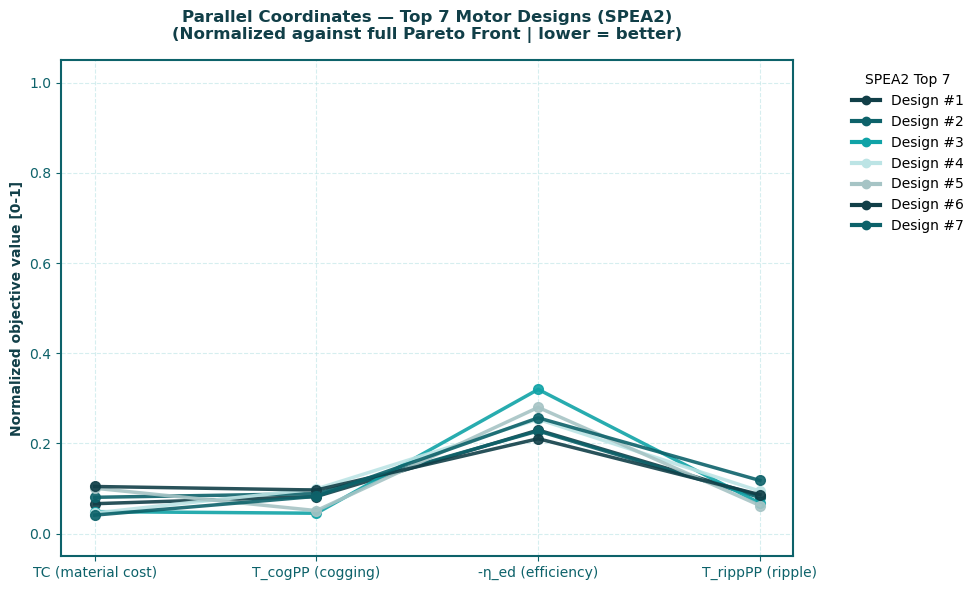

In [21]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import itertools

paleta_corporativa = ["#113f48", "#0d626a", "#10a3a7", "#bce4e5", "#a6c4c5"]
color_cycle = itertools.cycle(paleta_corporativa)

fig, ax = plt.subplots(figsize=(10, 6))

def normalize_context(F_subset, F_full):
    return (F_subset - F_full.min(axis=0)) / (F_full.max(axis=0) - F_full.min(axis=0) + 1e-10)

top7_norm = normalize_context(top7_F, F_best)

handles = []

for i, f in enumerate(top7_norm):
    color_actual = next(color_cycle)
    
    ax.plot(OBJECTIVE_NAMES, f, color=color_actual, linewidth=2.5, marker='o', markersize=7, alpha=0.9)
    
    handles.append(Line2D([0],[0], color=color_actual, lw=3, marker='o', label=f'Design #{i+1}'))

ax.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.25, 1), title="SPEA2 Top 7", frameon=False)

ax.set_title('Parallel Coordinates — Top 7 Motor Designs (SPEA2)\n(Normalized against full Pareto Front | lower = better)',
             fontweight='bold', color="#113f48", pad=15)
ax.set_ylabel('Normalized objective value [0-1]', color="#113f48", fontweight='bold')

ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.6, color="#bce4e5", linestyle='--')

for spine in ax.spines.values():
    spine.set_color("#0d626a")
    spine.set_linewidth(1.5)
ax.tick_params(colors="#0d626a", labelsize=10)

plt.tight_layout()
plt.show()

## reducir dimensionalidad sin perder efectividad

In [22]:
from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution
import numpy as np

class MotorSurrogateProblem(FloatProblem):
    """
    Clase especializada EXCLUSIVAMENTE para el experimento de reducción de datos.
    Recibe los modelos entrenados en cada iteración para evaluar los motores.
    """

    def __init__(self, modelos_entrenados):
        super().__init__()
        
        self.lower_bound = LOWER_BOUNDS
        self.upper_bound = UPPER_BOUNDS

        self.obj_directions = [
            self.MINIMIZE,   
            self.MINIMIZE,   
            self.MINIMIZE,   
            self.MINIMIZE    
        ]
        self.obj_labels = ['TC', 'T_cogPP', '-η_ed', 'T_rippPP']
        
        self.modelos = modelos_entrenados

    def number_of_objectives(self) -> int:
        return 4

    def number_of_constraints(self) -> int:
        return 0

    def name(self) -> str:
        return 'MotorSurrogateProblem'

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        x = np.array(solution.variables).reshape(1, -1)

        solution.objectives[0] = float(self.modelos['y1'].predict(x)[0])
        solution.objectives[1] = float(self.modelos['y2'].predict(x)[0])
        solution.objectives[2] = float(self.modelos['y3'].predict(x)[0])
        solution.objectives[3] = float(self.modelos['y4'].predict(x)[0])

        return solution

In [23]:
def experimento_reduccion_datos(df_completo):
    fracciones = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4]
    resultados_experimento = []

    Y_ref  = df_completo[['y1', 'y2', 'y3', 'y4']].values
    percentage_margin = 10
    ref_point = []
    
    for i in range(Y_ref.shape[1]):
        col_min = Y_ref[:, i].min()
        col_max = Y_ref[:, i].max()
        rango   = col_max - col_min
        ref_point.append(col_max + percentage_margin / 100 * rango)

    print('Reference point global:', [round(r, 4) for r in ref_point])
    HV_global = HyperVolume(ref_point)

    def run_and_evaluate(algorithm):
        algorithm.run()
        front = get_non_dominated_solutions(algorithm.result())
        F_arr = np.array([s.objectives for s in front])
        _, F  = front_to_arrays(front)

        return {
            'GD':          round(GD_ind.compute(F),          6),
            'IGD':         round(IGD_ind.compute(F),         6),
            'Epsilon':     round(Eps_ind.compute(F),         6),
            'Hypervolume': round(HV_global.compute(F_arr),   6),
            'PF_size':     len(F)
        }

    for frac in fracciones:
        print(f"\n--- Evaluando con {frac*100}% del dataset ({int(len(df_completo)*frac)} muestras) ---")
        
        df_reducido = df_completo.sample(frac=frac, random_state=42)
        X_data = df_reducido[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']]
        Y_data = df_reducido[['y1', 'y2', 'y3', 'y4']]
        
        X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)
        
        modelos_iteracion = {}
        r2_scores = {} 
        
        modelos_iteracion['y1'] = Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingRegressor(learning_rate=0.2, max_depth=3, min_samples_split=2, n_estimators=300, subsample=0.8, random_state=42))])
        modelos_iteracion['y2'] = Pipeline([('scaler', StandardScaler()), ('model', XGBRegressor(learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8, random_state=42, n_jobs=1))])
        modelos_iteracion['y3'] = Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingRegressor(learning_rate=0.05, max_depth=7, min_samples_split=2, n_estimators=300, subsample=0.8, random_state=42))])
        modelos_iteracion['y4'] = Pipeline([('scaler', StandardScaler()), ('model', XGBRegressor(learning_rate=0.05, max_depth=7, n_estimators=300, subsample=0.8, random_state=42, n_jobs=1))])
        
        for obj in ['y1', 'y2', 'y3', 'y4']:
            modelos_iteracion[obj].fit(X_train, Y_train[obj])
            r2_scores[f'R2_{obj}'] = round(modelos_iteracion[obj].score(X_test, Y_test[obj]), 4)
            
        problema = MotorSurrogateProblem(modelos_iteracion)
        
        algoritmo = SPEA2(
            problem=problema,
            population_size=500,               
            offspring_population_size=500,     
            mutation=PolynomialMutation(probability=1.0/6, distribution_index=20.0), 
            crossover=SBXCrossover(probability=0.9, distribution_index=20.0),        
            termination_criterion=StoppingByEvaluations(max_evaluations=50000)       
        )
        
        metricas = run_and_evaluate(algoritmo)
        
        resultado_actual = {
            'Porcentaje_Datos': frac * 100,
            'Tamano_Muestra': len(df_reducido)
        }
        resultado_actual.update(metricas)  
        resultado_actual.update(r2_scores) 
        
        resultados_experimento.append(resultado_actual)
        
        avg_r2 = sum(r2_scores.values()) / 4
        print(f"Completado: HV={metricas['Hypervolume']:.5f} | IGD={metricas['IGD']:.5f} | R2 Medio={avg_r2:.4f}")

    df_resultados = pd.DataFrame(resultados_experimento)
    return df_resultados

df_resultados_degradacion = experimento_reduccion_datos(df)

Reference point global: [np.float64(10.237), np.float64(0.6097), np.float64(-0.6366), np.float64(0.5642)]

--- Evaluando con 100.0% del dataset (1700 muestras) ---


[2026-03-27 00:40:41,442] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 00:40:41,449] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 00:40:42,896] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 00:40:42,896] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 00:46:19,822] [jmetal.core.algorithm] [DEBUG] Finished!


Completado: HV=0.57944 | IGD=0.00268 | R2 Medio=0.9760

--- Evaluando con 90.0% del dataset (1530 muestras) ---


[2026-03-27 00:46:22,639] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 00:46:22,641] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 00:46:24,382] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 00:46:24,383] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 00:52:06,799] [jmetal.core.algorithm] [DEBUG] Finished!


Completado: HV=0.57597 | IGD=0.00226 | R2 Medio=0.9748

--- Evaluando con 80.0% del dataset (1360 muestras) ---


...

Completado: HV=0.56356 | IGD=0.00269 | R2 Medio=0.9728

--- Evaluando con 50.0% del dataset (850 muestras) ---


[2026-03-27 01:09:25,587] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 01:09:25,593] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 01:09:26,987] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 01:09:26,987] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 01:15:01,039] [jmetal.core.algorithm] [DEBUG] Finished!


Completado: HV=0.56053 | IGD=0.00303 | R2 Medio=0.9614

--- Evaluando con 40.0% del dataset (680 muestras) ---


[2026-03-27 01:15:03,430] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 01:15:03,531] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 01:15:05,057] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 01:15:05,058] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 01:20:43,697] [jmetal.core.algorithm] [DEBUG] Finished!


Completado: HV=0.55702 | IGD=0.00225 | R2 Medio=0.9664


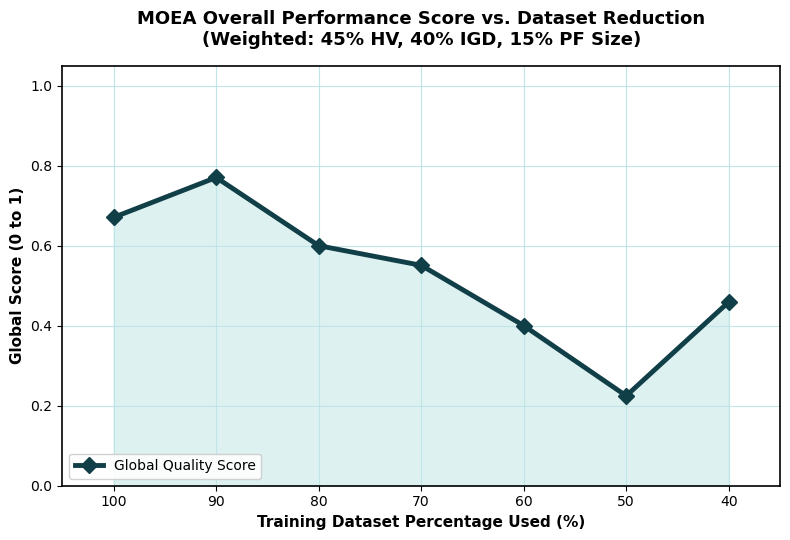

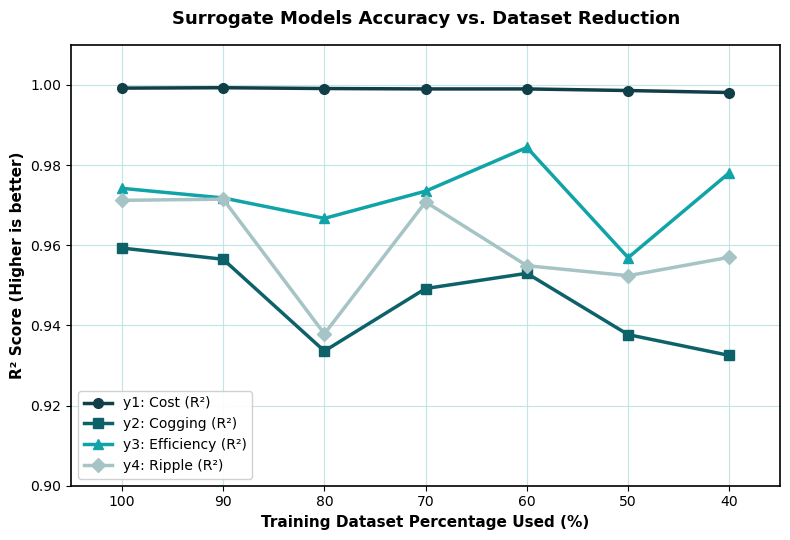

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

def graficar_informe_separado(df_resultados):
    df = df_resultados.copy()
    pesos = {'Hypervolume': 0.45, 'IGD': 0.40, 'PF_size': 0.15}
    
    min_hv, max_hv = df['Hypervolume'].min(), df['Hypervolume'].max()
    df['HV_Score'] = (df['Hypervolume'] - min_hv) / (max_hv - min_hv) if max_hv != min_hv else 1.0
    
    min_igd, max_igd = df['IGD'].min(), df['IGD'].max()
    df['IGD_Score'] = (max_igd - df['IGD']) / (max_igd - min_igd) if max_igd != min_igd else 1.0
    
    min_pf, max_pf = df['PF_size'].min(), df['PF_size'].max()
    df['PF_Score'] = (df['PF_size'] - min_pf) / (max_pf - min_pf) if max_pf != min_pf else 1.0
    
    df['Final_Score'] = (df['HV_Score'] * pesos['Hypervolume'] + 
                         df['IGD_Score'] * pesos['IGD'] + 
                         df['PF_Score'] * pesos['PF_size'])

    c1 = '#113f48' 
    c2 = '#0d626a' 
    c3 = '#10a3a7' 
    c4 = '#a6c4c5' 
    c5 = '#bce4e5' 
    c_text = 'black'

    fig1, ax1 = plt.subplots(figsize=(8, 5.5))
    
    ax1.set_xlim(df['Porcentaje_Datos'].max() + 5, df['Porcentaje_Datos'].min() - 5)
    
    ax1.plot(df['Porcentaje_Datos'], df['Final_Score'], 
             marker='D', color=c1, linewidth=3.5, markersize=8, label='Global Quality Score')
    ax1.fill_between(df['Porcentaje_Datos'], df['Final_Score'], 0, color=c5, alpha=0.5)
    
    ax1.set_xlabel('Training Dataset Percentage Used (%)', fontweight='bold', color=c_text, fontsize=11)
    ax1.set_ylabel('Global Score (0 to 1)', fontweight='bold', color=c_text, fontsize=11)
    plt.title('MOEA Overall Performance Score vs. Dataset Reduction\n(Weighted: 45% HV, 40% IGD, 15% PF Size)', 
              fontweight='bold', color=c_text, fontsize=13, pad=15)
    
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, color=c5, linestyle='-', linewidth=0.8, alpha=0.9)
    ax1.tick_params(axis='both', colors=c_text)
    
    for spine in ax1.spines.values():
        spine.set_color(c_text)
        spine.set_linewidth(1.2)
        
    legend1 = ax1.legend(loc='lower left', fontsize=10, framealpha=0.9)
    for text in legend1.get_texts():
        text.set_color(c_text)

    fig1.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(8, 5.5))
    
    ax2.set_xlim(df['Porcentaje_Datos'].max() + 5, df['Porcentaje_Datos'].min() - 5)
    
    ax2.plot(df['Porcentaje_Datos'], df['R2_y1'], marker='o', color=c1, linewidth=2.5, markersize=7, label='y1: Cost (R²)')
    ax2.plot(df['Porcentaje_Datos'], df['R2_y2'], marker='s', color=c2, linewidth=2.5, markersize=7, label='y2: Cogging (R²)')
    ax2.plot(df['Porcentaje_Datos'], df['R2_y3'], marker='^', color=c3, linewidth=2.5, markersize=7, label='y3: Efficiency (R²)')
    ax2.plot(df['Porcentaje_Datos'], df['R2_y4'], marker='D', color=c4, linewidth=2.5, markersize=7, label='y4: Ripple (R²)')

    ax2.set_xlabel('Training Dataset Percentage Used (%)', fontweight='bold', color=c_text, fontsize=11)
    ax2.set_ylabel('R² Score (Higher is better)', fontweight='bold', color=c_text, fontsize=11)
    plt.title('Surrogate Models Accuracy vs. Dataset Reduction', fontweight='bold', color=c_text, fontsize=13, pad=15)
    
    ax2.set_ylim(0.90, 1.01)
    ax2.grid(True, color=c5, linestyle='-', linewidth=0.8, alpha=0.9)
    ax2.tick_params(axis='both', colors=c_text)
    
    for spine in ax2.spines.values():
        spine.set_color(c_text)
        spine.set_linewidth(1.2)
        
    legend2 = ax2.legend(loc='best', fontsize=10, framealpha=0.9)
    for text in legend2.get_texts():
        text.set_color(c_text)

    fig2.tight_layout()
    plt.show()

graficar_informe_separado(df_resultados_degradacion)